# Statistics for Michel electron candidate (28116 full run)

### Created by Shu, 20251130---

### To fulfill the requirement of Anselmo!

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## PeakFinder (based on merged wvfCoin result):

In [25]:
import matplotlib.pyplot as plt
import numpy as np


peakFinder_muTime = []
peakFinder_miTime = []
peakFinder_miCoin = []

# Open the text file and process each line
with open('./statResult_MSp5MH8/peakFinder_muonTime.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_muTime.append(number)
            except ValueError:
                print(f"[Muon] Could not convert {parts[1].strip()} to an integer.")

with open('./statResult_MSp5MH8/peakFinder_michelTime.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miTime.append(number)
            except ValueError:
                print(f"[Michel] Could not convert {parts[1].strip()} to an integer.")

with open('./statResult_MSp5MH8/peakFinder_michelCoincidence.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miCoin.append(number)
            except ValueError:
                print(f"[Coin] Could not convert {parts[1].strip()} to an integer.")




#Muon lifetime---
# Element-wise subtraction: (mi - mu) for each corresponding element
mu_lifetime = [mi - mu for mi, mu in zip(peakFinder_miTime, peakFinder_muTime)]






print("Length of peakFinder_muTime:", len(peakFinder_muTime))
print("Length of peakFinder_miTime:", len(peakFinder_miTime))
print("Length of peakFinder_miCoin:", len(peakFinder_miCoin))
print("\nLength of mu_lifetime: ", len(mu_lifetime))




Length of peakFinder_muTime: 4775
Length of peakFinder_miTime: 4775
Length of peakFinder_miCoin: 4775

Length of mu_lifetime:  4775


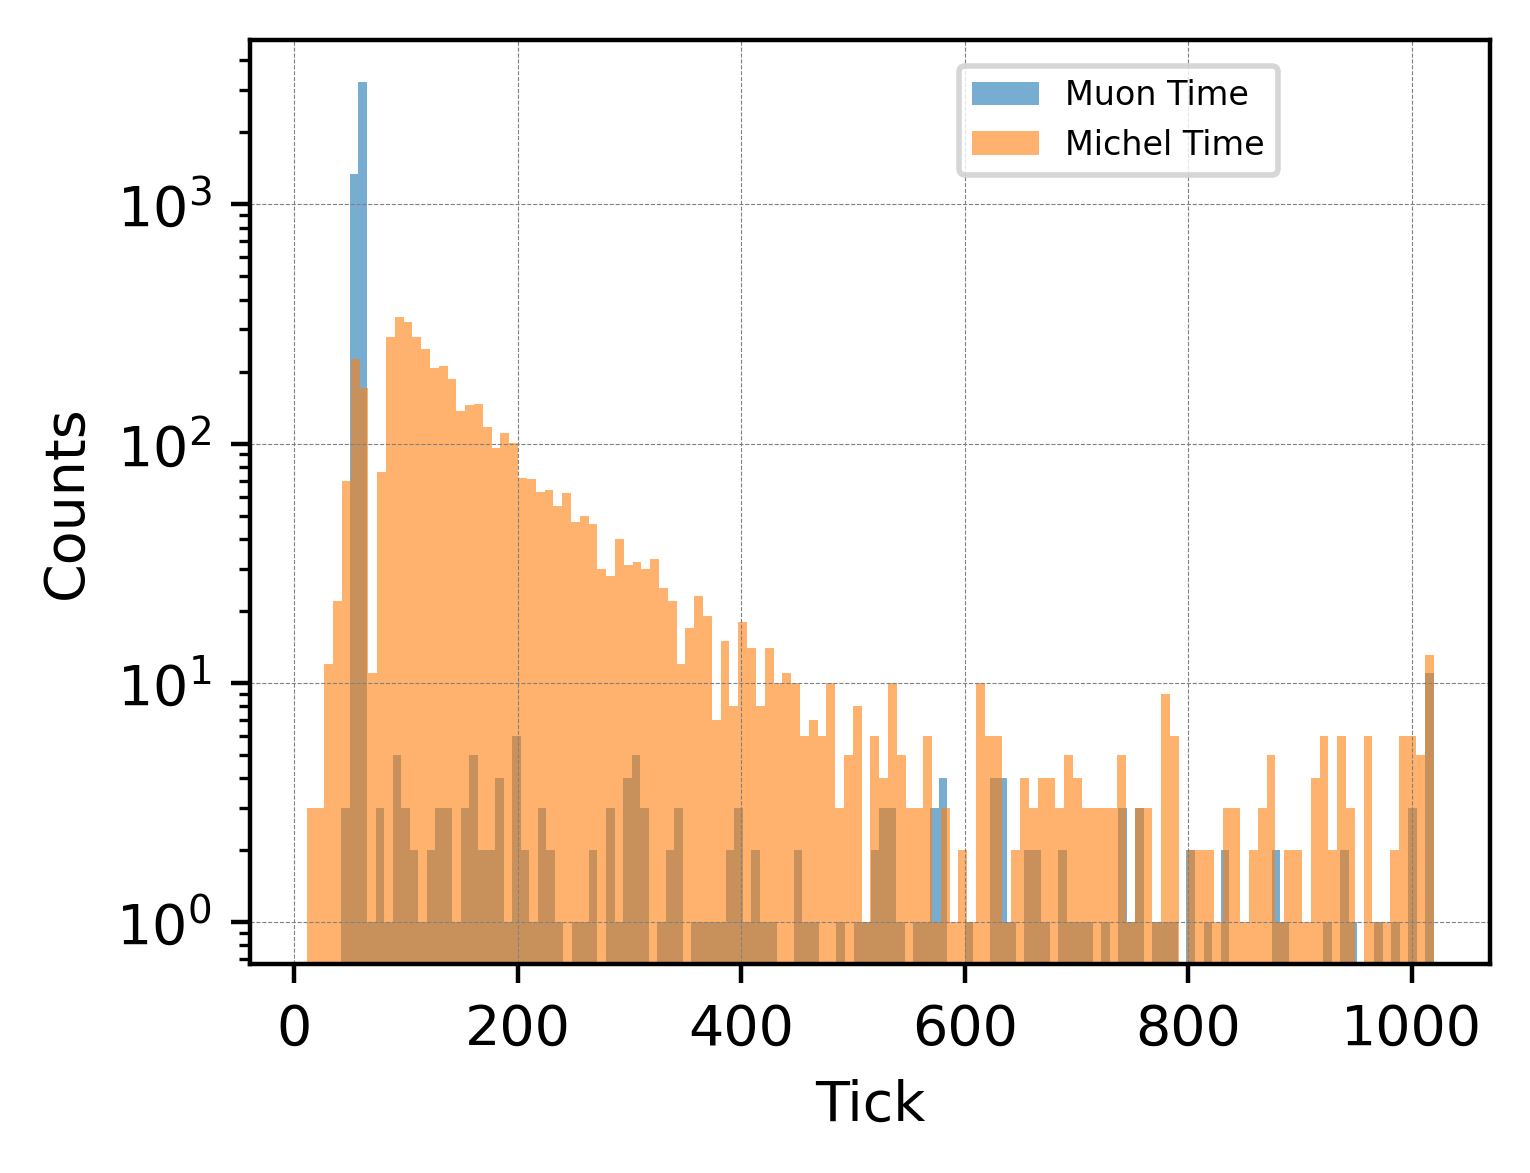


Lifetime distribution:
# Initial Candidates [-16000, 16000]:  4775
# Initial Candidates [0, 16000]:  4366 (91.43%)


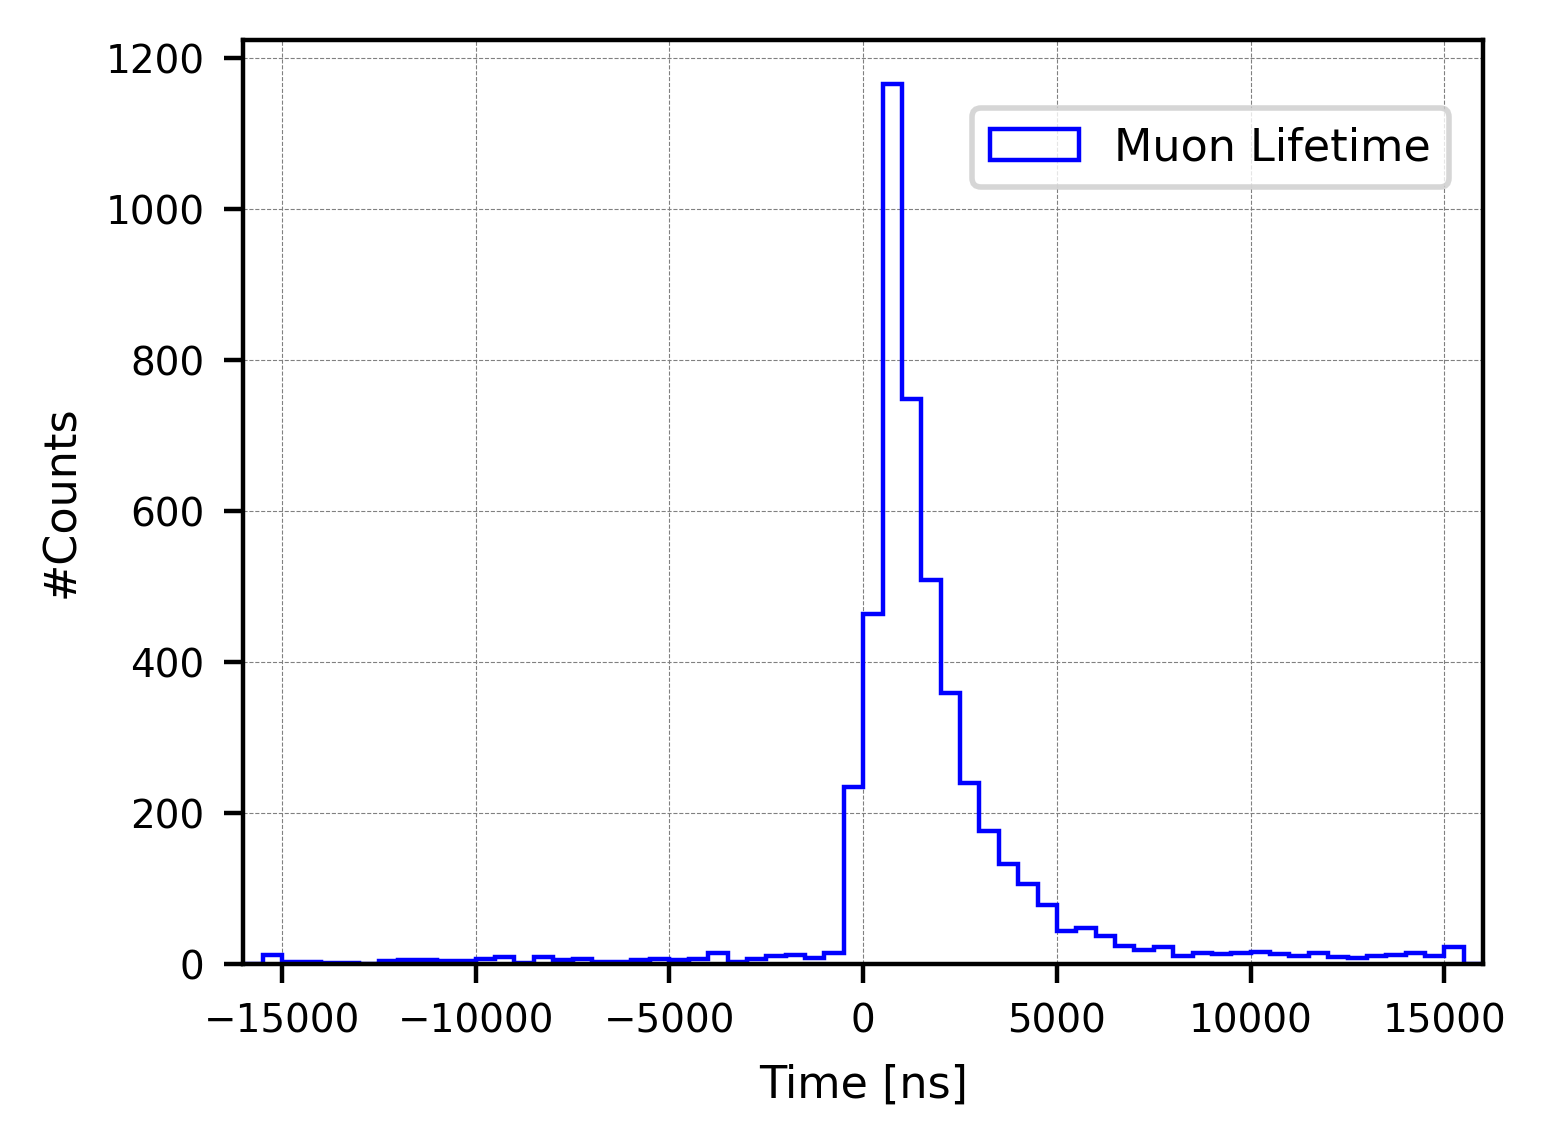

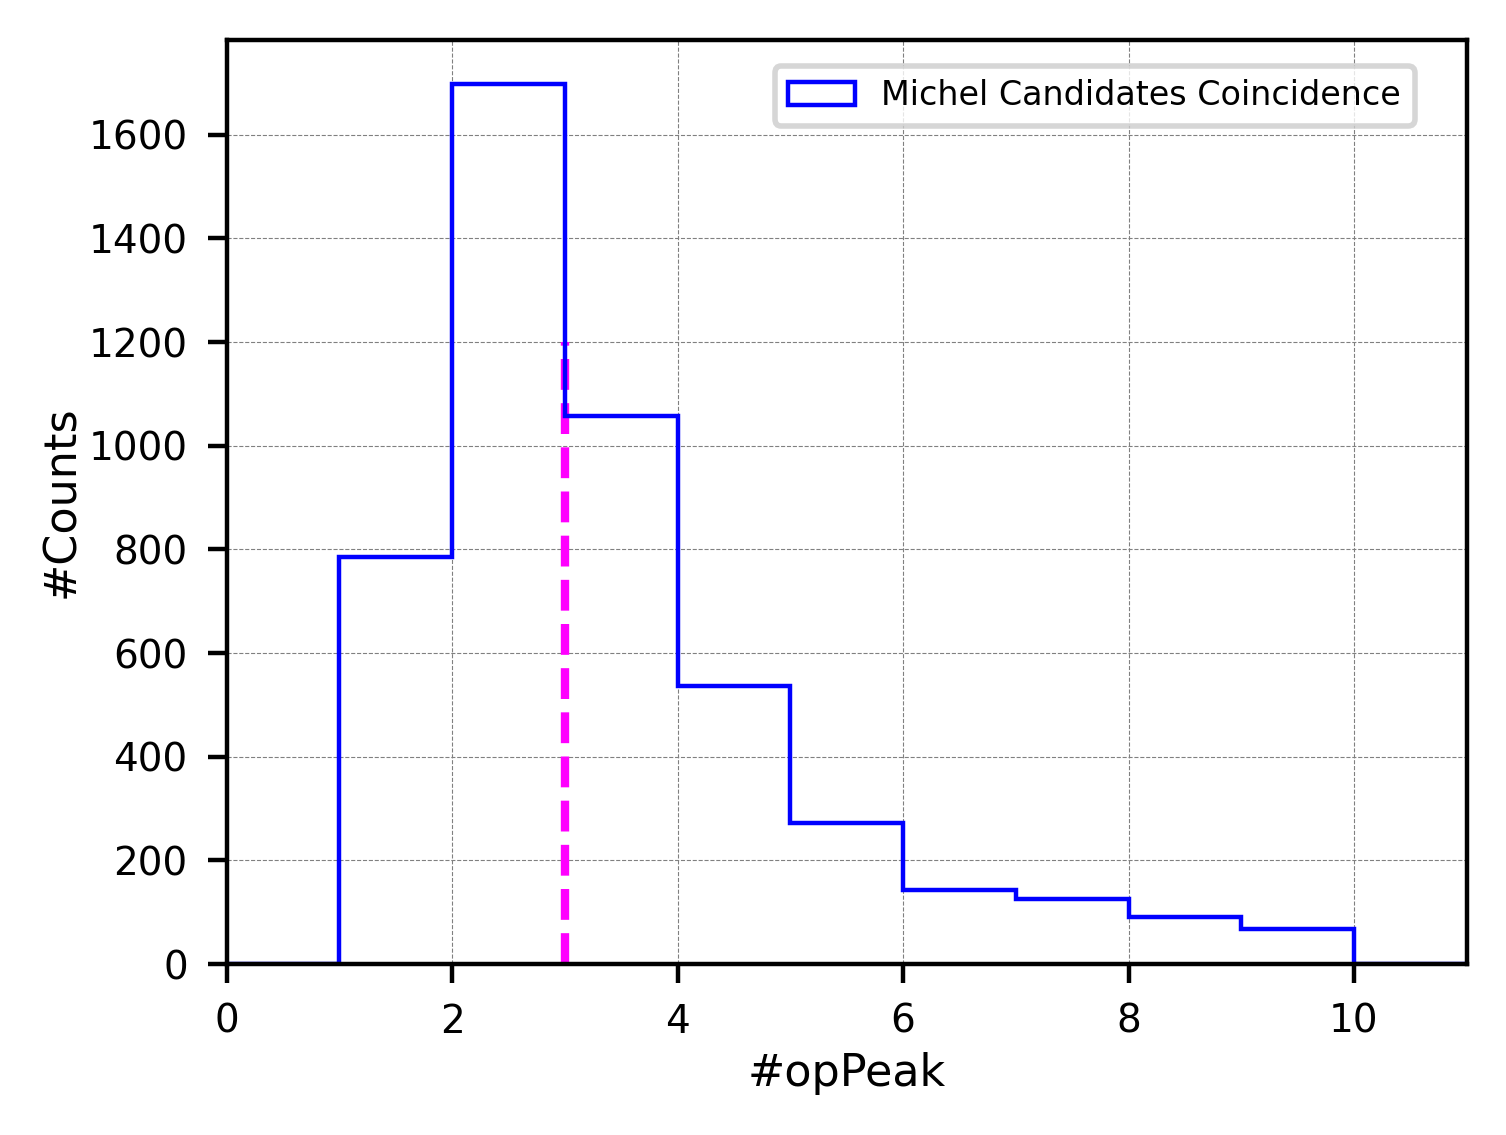

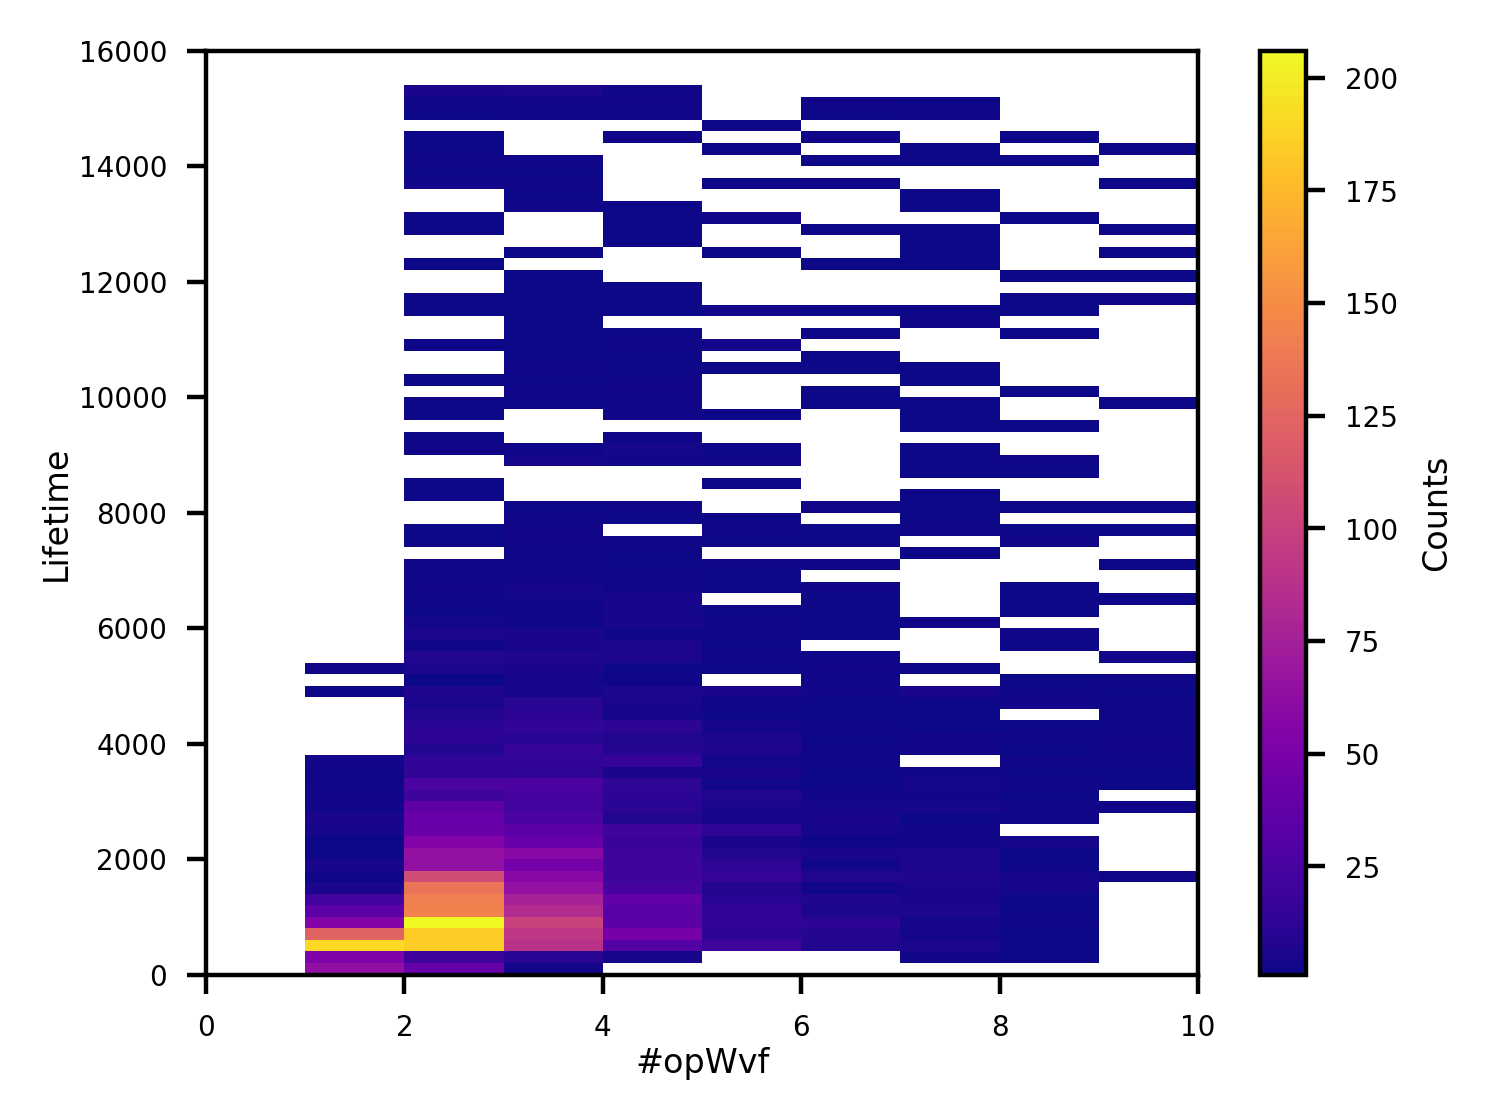

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Plot histograms on the same canvas
plt.hist(peakFinder_muTime, bins=128, alpha=0.6, label='Muon Time')
plt.hist(peakFinder_miTime, bins=128, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
#plt.title('Histogram of muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()








# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
mu_lifetime_ns = [value * 16 for value in mu_lifetime]
print("\nLifetime distribution:")
print("# Initial Candidates [-16000, 16000]: ", len(mu_lifetime_ns))

# Apply test cut
mu_lifetime_ns_test = [val for val in mu_lifetime_ns if 0 < val < 16000]
print("# Initial Candidates [0, 16000]: ", len(mu_lifetime_ns_test), "({:.2f}%)".format(len(mu_lifetime_ns_test)/len(mu_lifetime_ns)*100))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(-16000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()









# Michel coincidence distribution------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([3, 3], [0, 1200], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(peakFinder_miCoin, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=0.8, label='Michel Candidates Coincidence')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

plt.xlim(0, 11)
#plt.ylim(0, 1200)
plt.xlabel('#opPeak', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






#Lifetime vs opWvf (Original)===============================================

plt.figure(figsize=(4,3),dpi=400)



# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(peakFinder_miCoin, mu_lifetime_ns, bins=(10, 160), range=[[0, 10], [-16000, 16000]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

# Labels and styling
plt.xlim(0, 10)
plt.ylim(0, 16000) #(-16000, 16000)
plt.xlabel('#opWvf', labelpad=1, fontsize=6)
plt.ylabel('Lifetime', labelpad=1, fontsize=6)
#plt.title('After Space Cut', fontsize=7)
plt.tick_params(labelsize=5)




Keep #coincidence >=  3 :
# Purified Candidates [-16000, 16000]:  2292
# Purified Candidates [0, 16000]:  2123
# Purified Candidates [500, 16000]:  2024


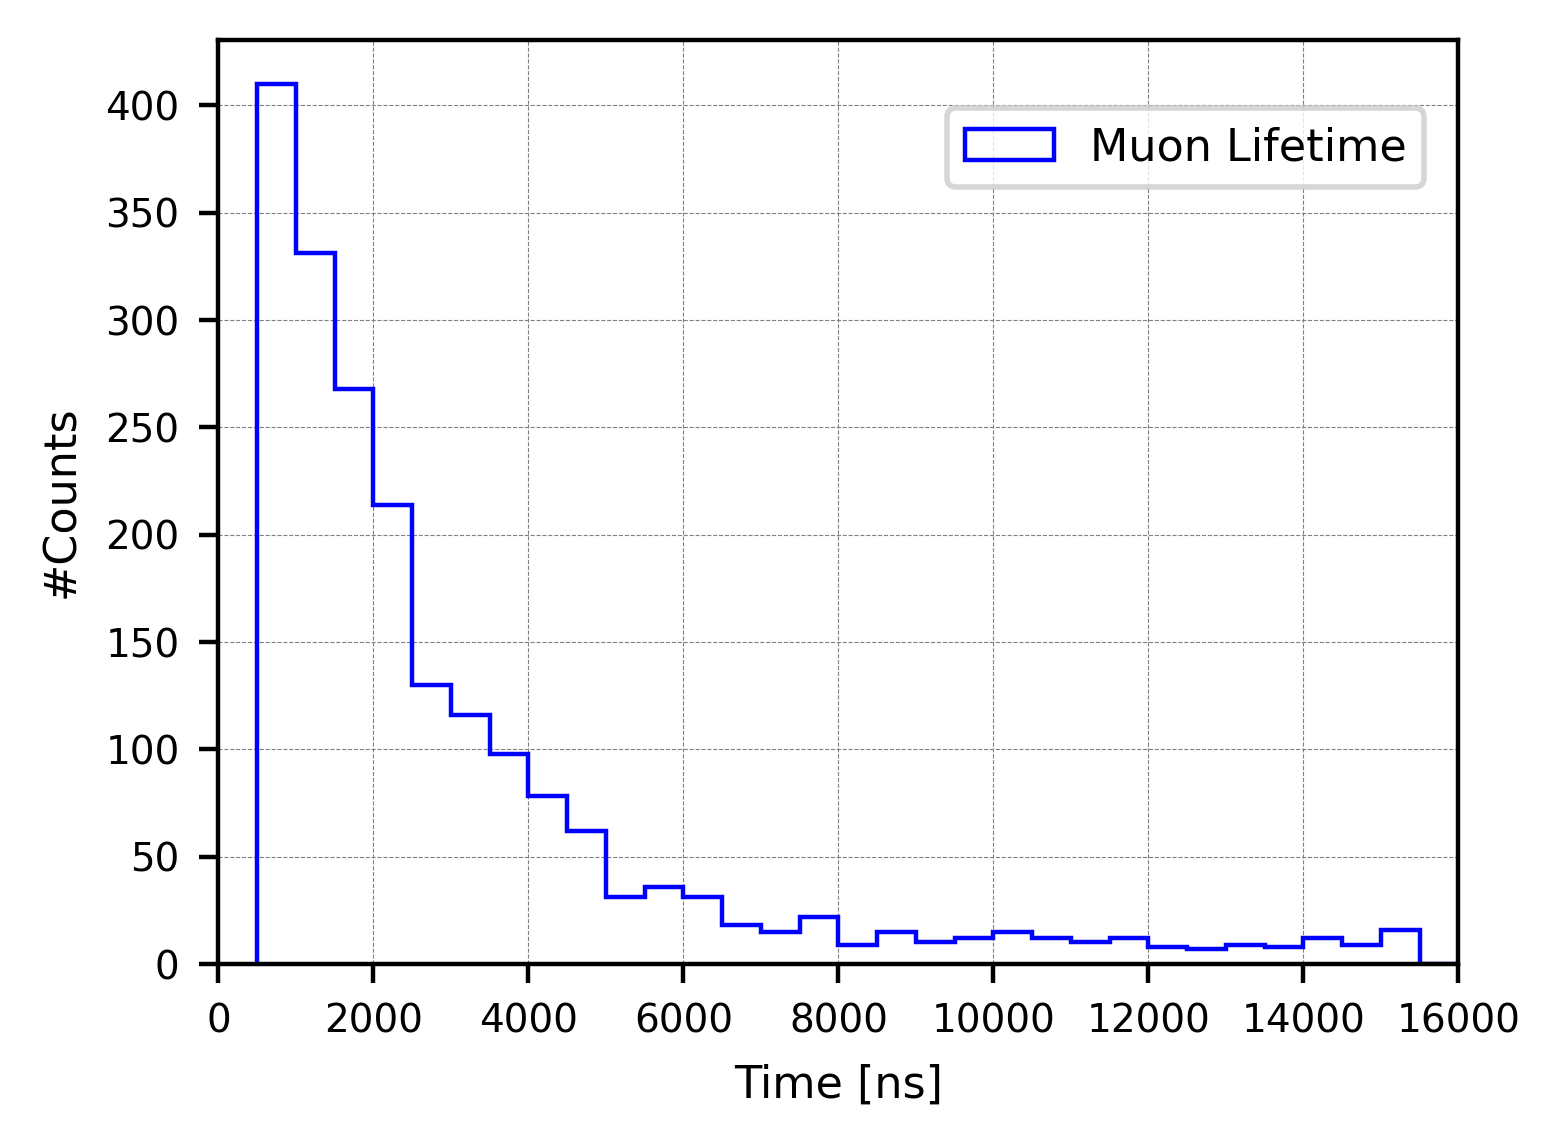


Least Square Fitting:==================

Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 410 ± 20.2
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 331 ± 18.2
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 268 ± 16.4
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 214 ± 14.6
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 130 ± 11.4
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 116 ± 10.8
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 98 ± 9.9
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 78 ± 8.8
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 62 ± 7.9
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 31 ± 5.6
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 36 ± 6.0
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 31 ± 5.6
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 18 ± 4.2
Bin 14: Range = [7000, 7500) | Center = 725

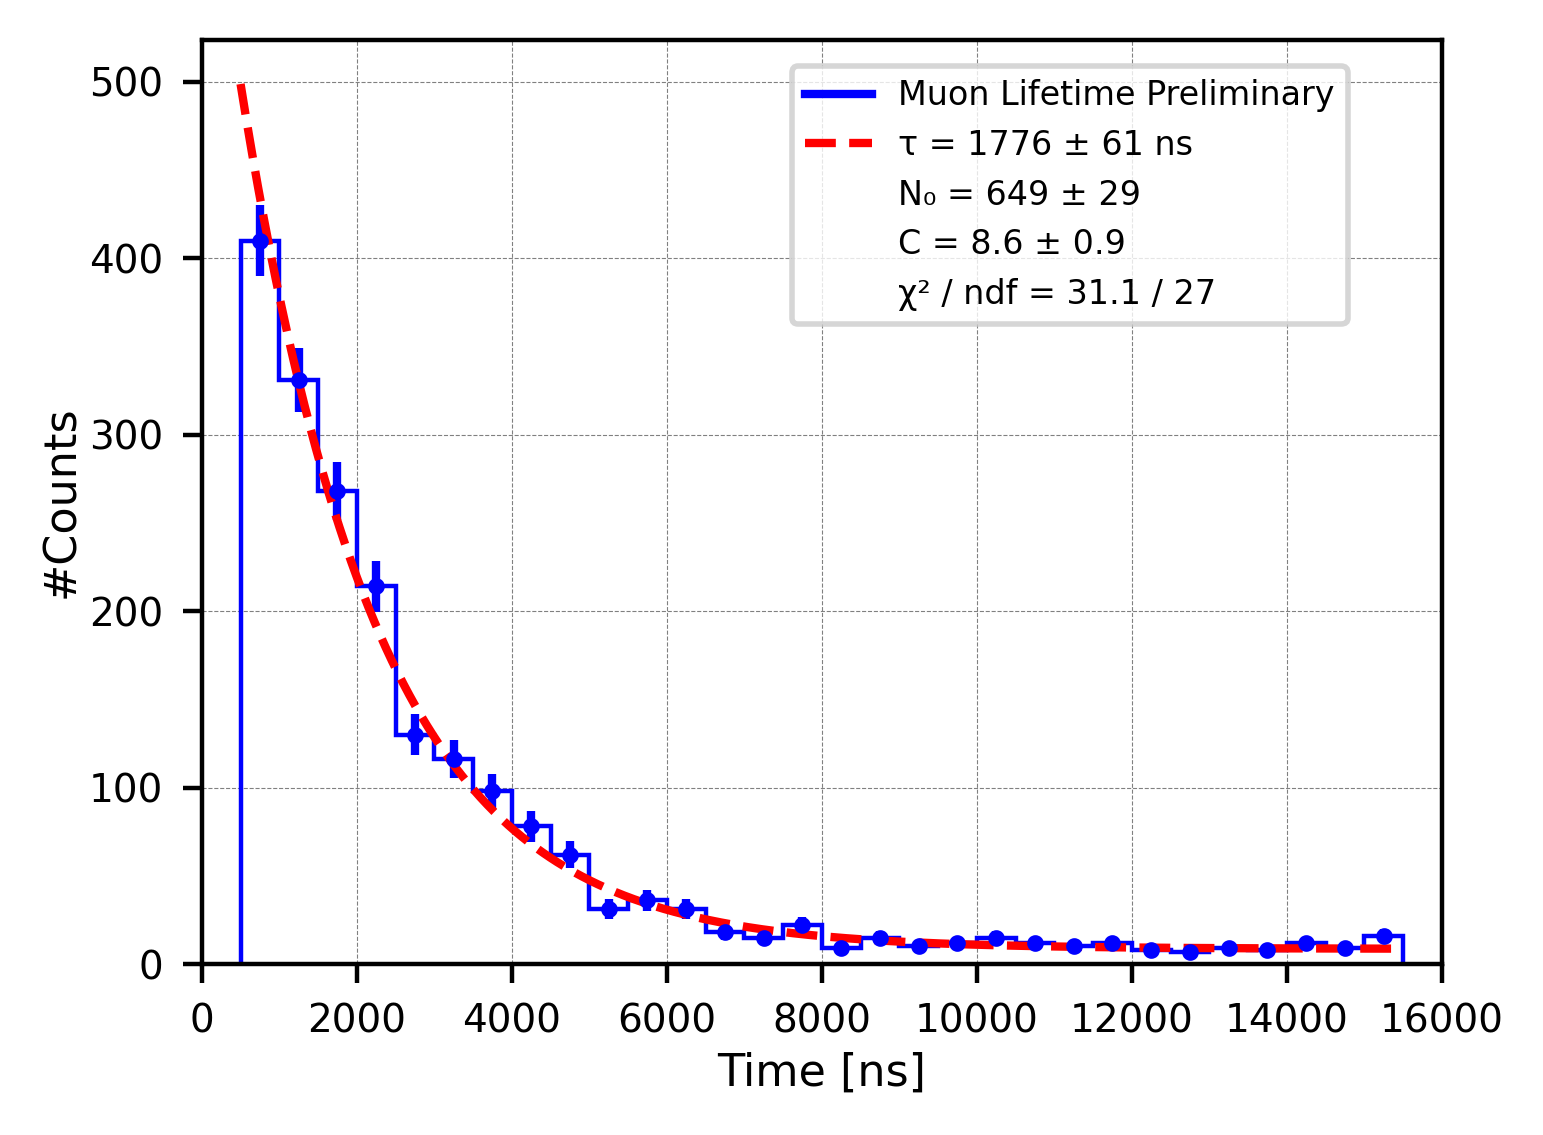

In [27]:
#Remove candidates with coincidence <3-----------------------------------------------
mu_lifetime_ns_purified = []

thre = 3

for i in range(0, len(peakFinder_miCoin)):
    coin = peakFinder_miCoin[i]
    time = mu_lifetime_ns[i]

    if coin >= thre:#-----------------
        mu_lifetime_ns_purified.append(time)
    
print("Keep #coincidence >= ", thre, ":")    
print("# Purified Candidates [-16000, 16000]: ", len(mu_lifetime_ns_purified))

#Test-------
mu_lifetime_ns_purified_00 = [val for val in mu_lifetime_ns_purified if 0 <= val <= 16000]
mu_lifetime_ns_purified_500 = [val for val in mu_lifetime_ns_purified if 500 <= val <= 16000]
print("# Purified Candidates [0, 16000]: ", len(mu_lifetime_ns_purified_00))
print("# Purified Candidates [500, 16000]: ", len(mu_lifetime_ns_purified_500))






# Muon Lifetime distribution (NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns_purified_00, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(0, 16000)
#plt.ylim(0, 400)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()







#Plot---------------------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\nLeast Square Fitting:==================")

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create the histogram and capture counts, bin edges, etc.
n, bin_edges, patches = plt.hist(mu_lifetime_ns_purified_500, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8,
                                 label='Muon Lifetime Preliminary')

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)  # Avoid zero division error for empty bins

# Plot error bars on the histogram
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2)

# Define the exponential fitting function: N(t) = N0 * exp(-t/tau0) + C
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Least Squares Method------
popt, pcov = curve_fit(exp_func, bin_centers, n, p0=[max(n), 1000, 1], sigma=yerr, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")

# Print results to terminal
print("\nFitted parameters:")
print("N0 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau0 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate chi-squared
expected = exp_func(bin_centers, *popt)
expected = np.clip(expected, 1e-10, None)  # Avoid division by zero
residuals = n - expected
chi2 = np.sum((residuals / yerr_plot) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

# Print goodness-of-fit summary
print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print detailed bin-by-bin information
for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
    print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; "
          f"residual = {res:.2f}; residual / yerr = {res / err:.2f}")

# Plot and legend----------
n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

# Dummy handles for text-only legend entries
dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

# Histogram handle
hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
#plt.ylim(0.9, 400)
#plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()




Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 82 ± 9.1
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 60 ± 7.7
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 71 ± 8.4
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 45 ± 6.7
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 39 ± 6.2
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 32 ± 5.7
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 31 ± 5.6
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 27 ± 5.2
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 28 ± 5.3
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 10 ± 3.2
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 14 ± 3.7
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 11 ± 3.3
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 7 ± 2.6
Bin 14: Range = [7000, 7500) | Center = 7250 ns | Entries = 7 ± 2.6
Bin 15: Range = [7500, 8000) 

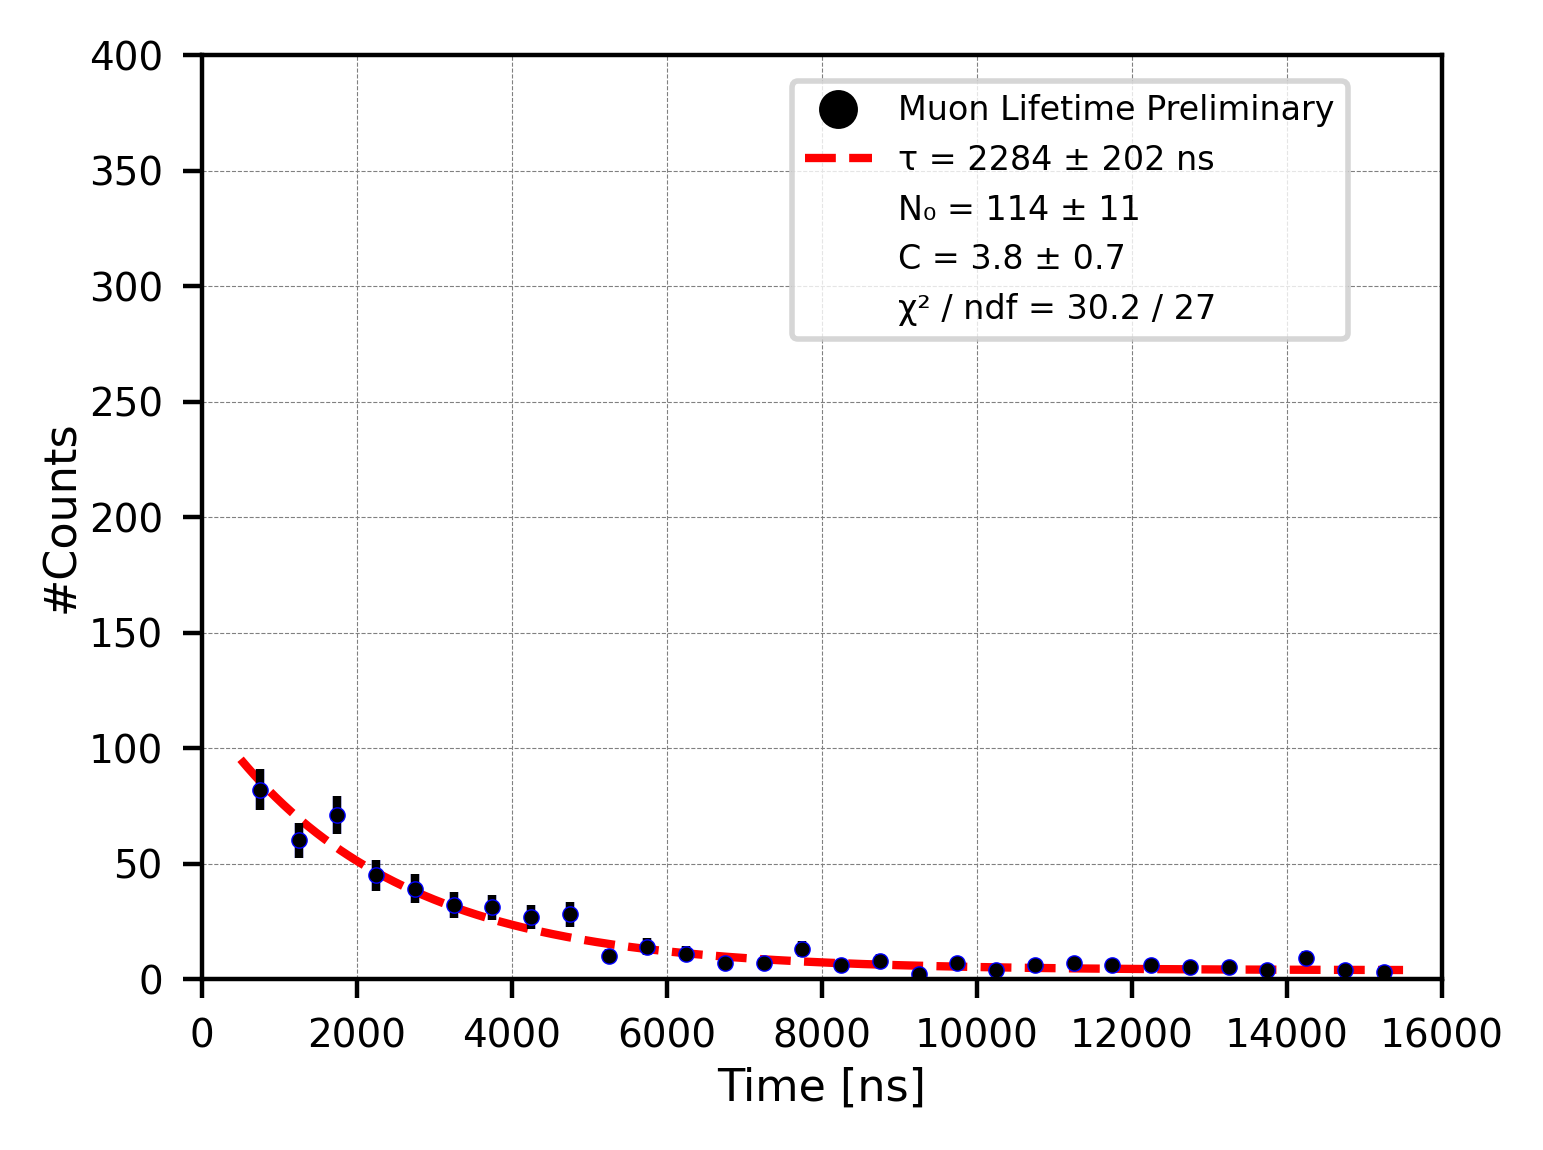

In [17]:
# Plot------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)


n, bin_edges = np.histogram(mu_lifetime_ns_purified_500, bins=bins, range=(range_min, range_max))


# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_weight = np.where(n == 0, 1, yerr)

# Plot error bars on the histogram
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2)

# Define the exponential fitting function: N(t) = N0 * exp(-t/tau0) + C
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C


#Least Squares Method------
popt, pcov = curve_fit(exp_func, bin_centers, n, p0=[max(n), 1000, 1], sigma=yerr_weight, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties



# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")



# Print results to terminal
print("\nFitted parameters:")
print("N0 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau0 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate chi-squared
residuals = n - exp_func(bin_centers, *popt)
chi2 = np.sum((residuals / yerr_weight) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

# Plot and legend----------
n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

# Dummy handles for text-only legend entries
dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

#To remove line of histogram, 20250522---
# Histogram handle
#hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

hist_handle = plt.Line2D([], [], color='black', marker='o', linestyle='', label='Muon Lifetime Preliminary')
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='black', markersize=1.5)


plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
plt.ylim(0, 400)
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()

<br />
<br />
<br />
<br />

## To check the validity of single-exponential fitting:

Long-lifetime sample:  3909 entries, mean = 2198.2 ns
Short-lifetime sample: 850 entries, mean = 590.4 ns
Total sample: 4759 entries, mean = 1911.0 ns


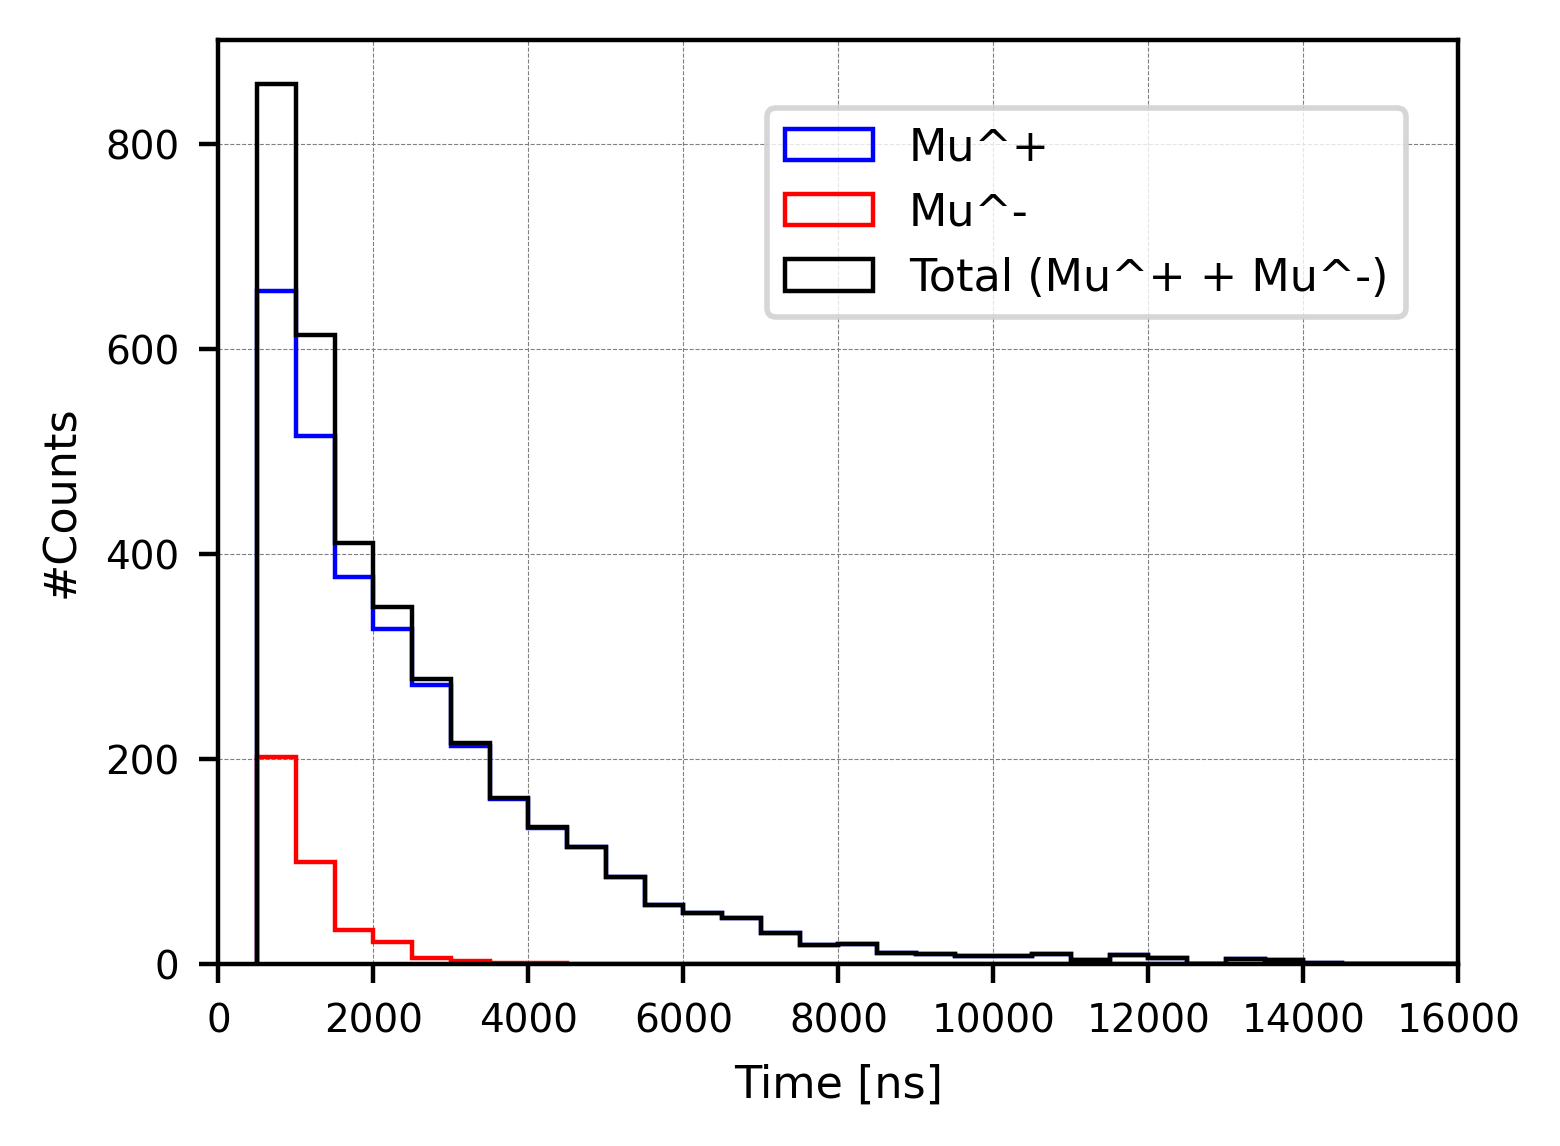

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit




# -----------------------------
# Parameters (you can change)
# -----------------------------
tau_long = 2200.0   # ns
tau_short = 570.0   # ns

n_short = 850      # size of second sample
n_long = int(np.floor(n_short * 4.6))      # size of first sample


# -----------------------------
# Generate samples
# -----------------------------
# numpy uses scale = mean lifetime = tau
sample_short = np.random.exponential(scale=tau_short, size=n_short)
sample_long = np.random.exponential(scale=tau_long, size=n_long)

# -----------------------------
# Convert to Python lists
# -----------------------------
list_long = sample_long.tolist()
list_short = sample_short.tolist()
list_total = list_long + list_short

# Quick sanity check
print(f"Long-lifetime sample:  {len(list_long)} entries, mean = {np.mean(list_long):.1f} ns")
print(f"Short-lifetime sample: {len(list_short)} entries, mean = {np.mean(list_short):.1f} ns")

print(f"Total sample: {len(list_total)} entries, mean = {np.mean(list_total):.1f} ns")





# Muon Lifetime distribution (NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(list_long, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Mu^+')
plt.hist(list_short, bins=bins, range=(range_min, range_max),
         edgecolor='red', histtype='step', linewidth=0.8,
         label='Mu^-')
plt.hist(list_total, bins=bins, range=(range_min, range_max),
         edgecolor='black', histtype='step', linewidth=0.8,
         label='Total (Mu^+ + Mu^-)')



plt.xlim(0, 16000)
#plt.ylim(0, 400)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()


#### Do fittings: 


Least Square Fitting ==================
N0   = 926.11 ± 28.07
tau  = 2146.92 ± 46.80 ns
C    = -0.54 ± 0.52
χ² / ndf = 28.3 / 27 = 1.05

Bin-by-bin details:
Bin  0: center=   750 ns | n=   657 ±  25.6 | exp= 652.51 | res/σ=  0.18
Bin  1: center=  1250 ns | n=   515 ±  22.7 | exp= 516.83 | res/σ= -0.08
Bin  2: center=  1750 ns | n=   378 ±  19.4 | exp= 409.34 | res/σ= -1.61
Bin  3: center=  2250 ns | n=   327 ±  18.1 | exp= 324.19 | res/σ=  0.16
Bin  4: center=  2750 ns | n=   272 ±  16.5 | exp= 256.72 | res/σ=  0.93
Bin  5: center=  3250 ns | n=   213 ±  14.6 | exp= 203.27 | res/σ=  0.67
Bin  6: center=  3750 ns | n=   161 ±  12.7 | exp= 160.93 | res/σ=  0.01
Bin  7: center=  4250 ns | n=   133 ±  11.5 | exp= 127.38 | res/σ=  0.49
Bin  8: center=  4750 ns | n=   114 ±  10.7 | exp= 100.81 | res/σ=  1.24
Bin  9: center=  5250 ns | n=    85 ±   9.2 | exp=  79.75 | res/σ=  0.57
Bin 10: center=  5750 ns | n=    57 ±   7.5 | exp=  63.07 | res/σ= -0.80
Bin 11: center=  6250 ns | n=    50 ±  

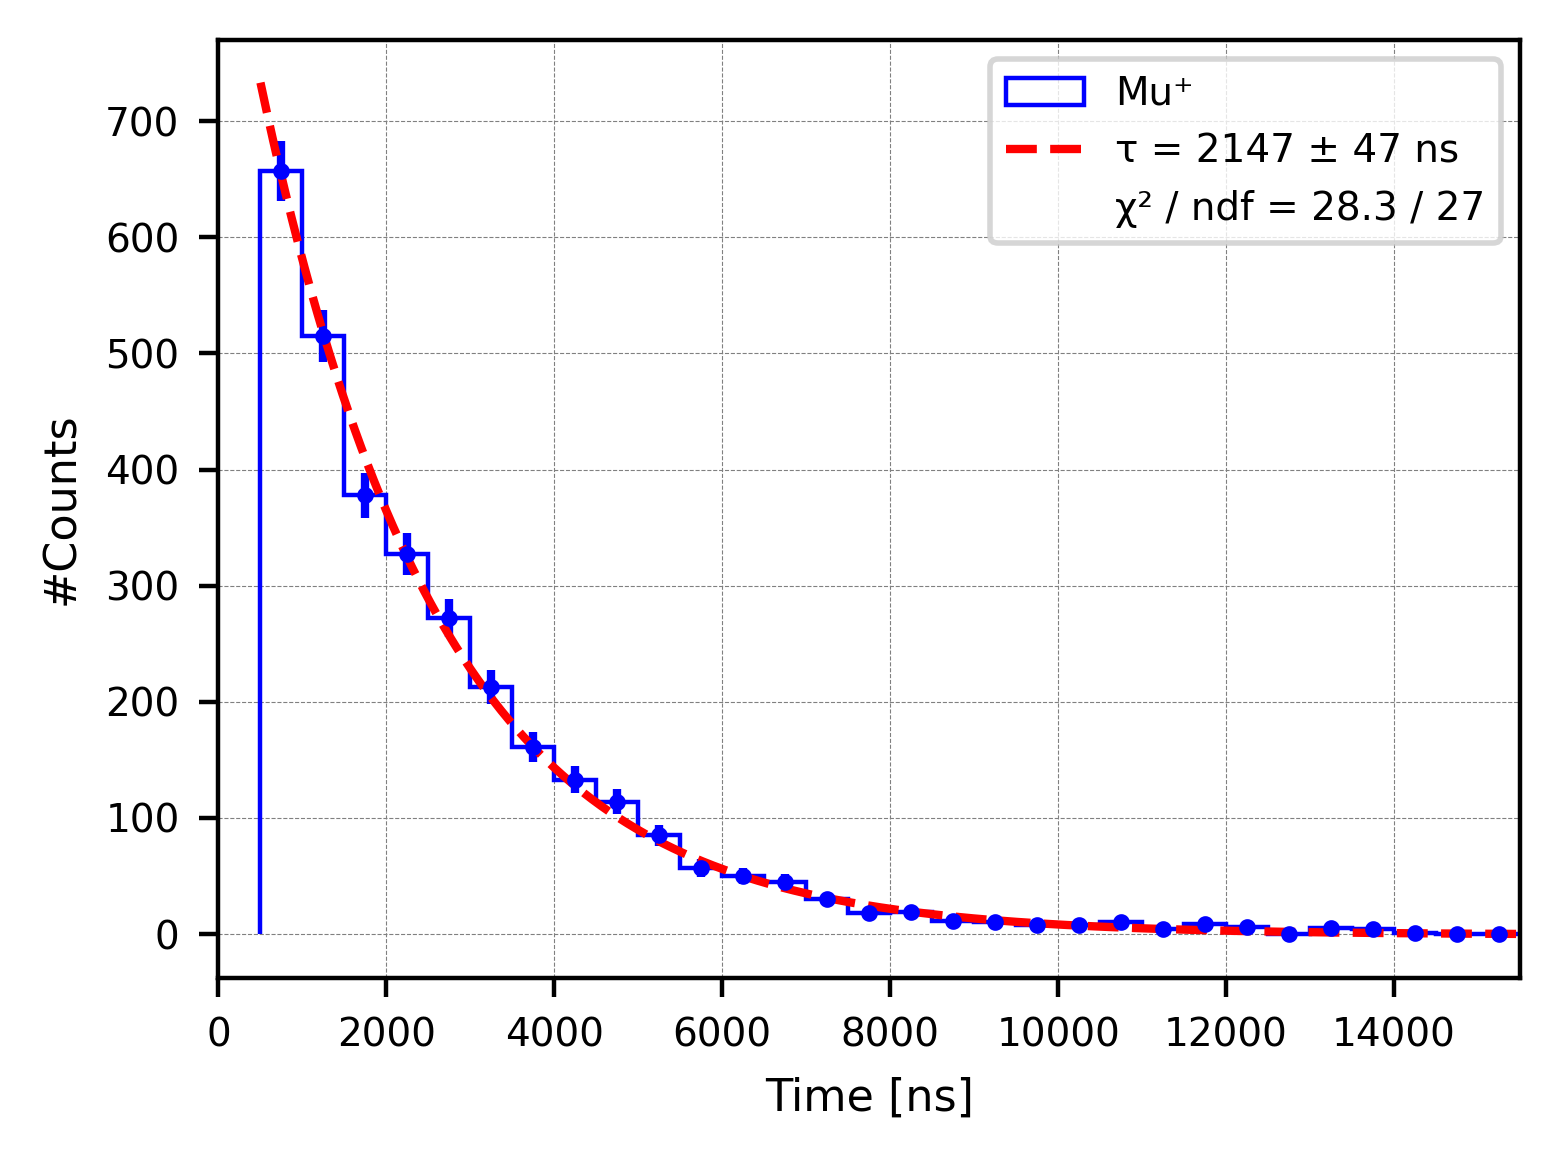


Least Square Fitting ==================
N0   = 729.00 ± 85.85
tau  = 594.55 ± 33.44 ns
C    = -0.02 ± 0.21
χ² / ndf = 3.5 / 27 = 0.13

Bin-by-bin details:
Bin  0: center=   750 ns | n=   202 ±  14.2 | exp= 206.47 | res/σ= -0.31
Bin  1: center=  1250 ns | n=    99 ±   9.9 | exp=  89.04 | res/σ=  1.00
Bin  2: center=  1750 ns | n=    33 ±   5.7 | exp=  38.39 | res/σ= -0.94
Bin  3: center=  2250 ns | n=    21 ±   4.6 | exp=  16.55 | res/σ=  0.97
Bin  4: center=  2750 ns | n=     6 ±   2.4 | exp=   7.13 | res/σ= -0.46
Bin  5: center=  3250 ns | n=     3 ±   1.7 | exp=   3.06 | res/σ= -0.04
Bin  6: center=  3750 ns | n=     1 ±   1.0 | exp=   1.31 | res/σ= -0.31
Bin  7: center=  4250 ns | n=     1 ±   1.0 | exp=   0.56 | res/σ=  0.44
Bin  8: center=  4750 ns | n=     0 ±   0.0 | exp=   0.23 | res/σ= -0.23
Bin  9: center=  5250 ns | n=     0 ±   0.0 | exp=   0.09 | res/σ= -0.09
Bin 10: center=  5750 ns | n=     0 ±   0.0 | exp=   0.03 | res/σ= -0.03
Bin 11: center=  6250 ns | n=     0 ±   0

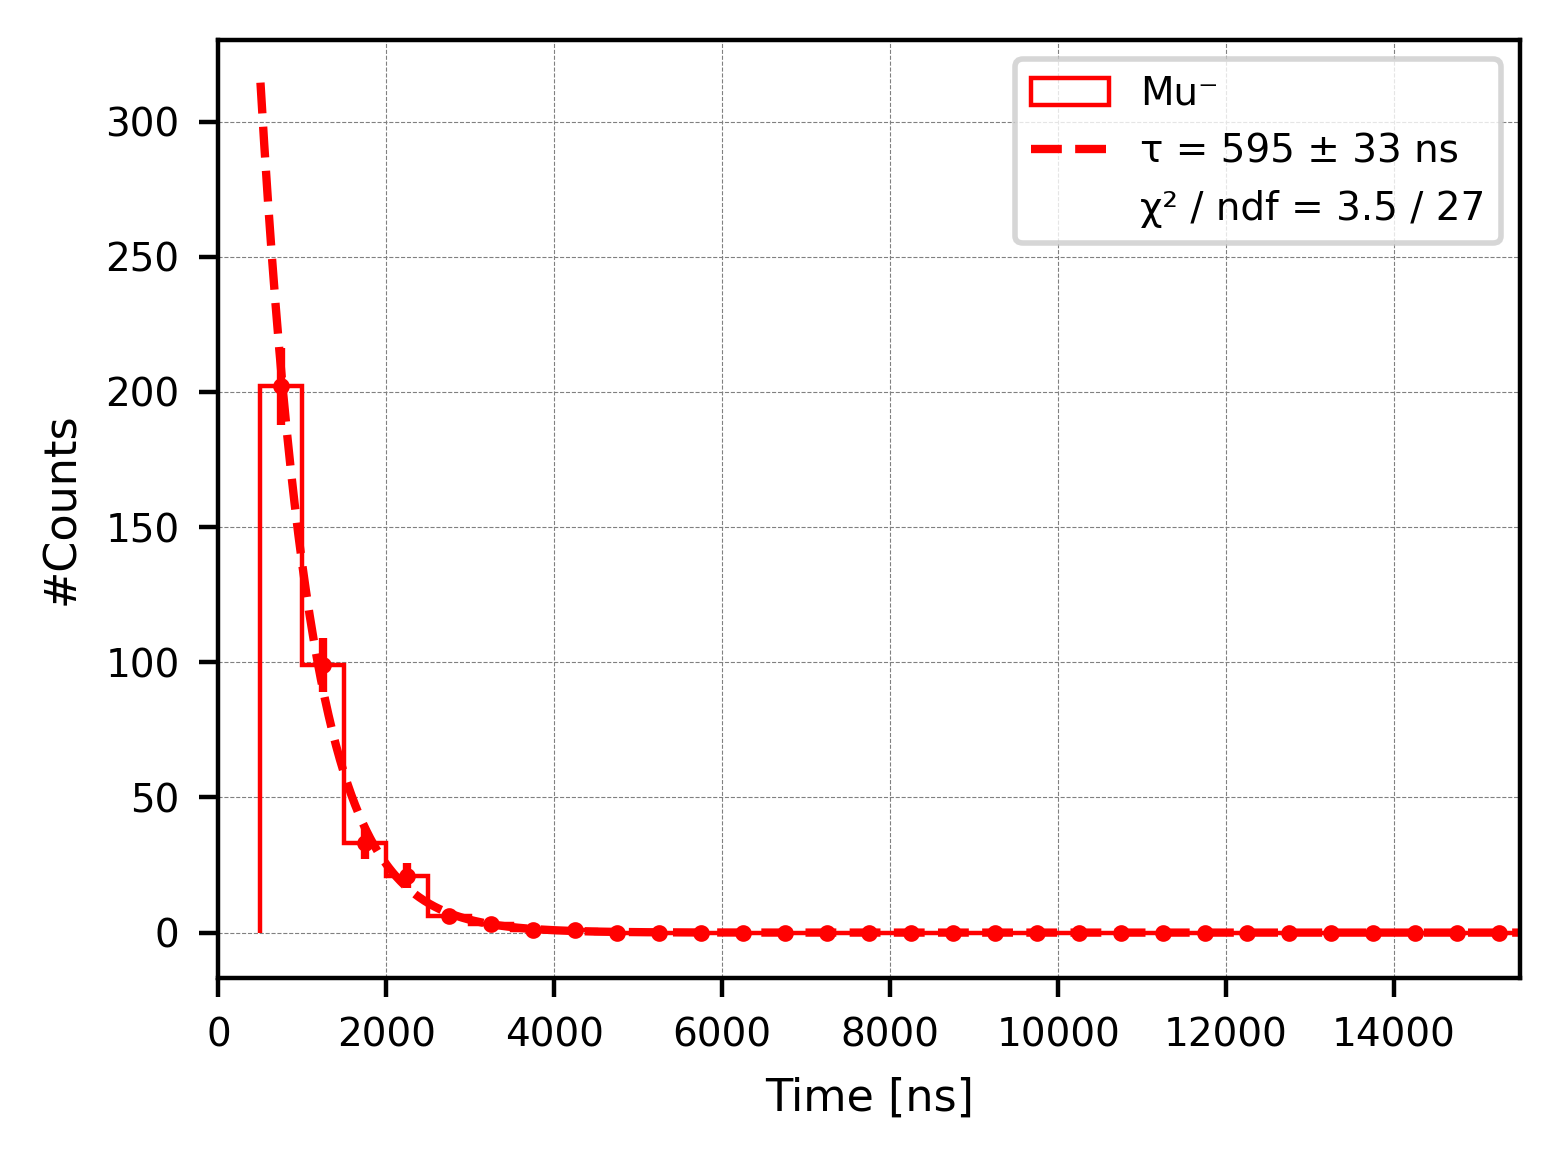


Least Square Fitting ==================
N0   = 1152.62 ± 34.05
tau  = 1952.57 ± 40.14 ns
C    = 0.21 ± 0.48
χ² / ndf = 40.0 / 27 = 1.48

Bin-by-bin details:
Bin  0: center=   750 ns | n=   859 ±  29.3 | exp= 785.21 | res/σ=  2.52
Bin  1: center=  1250 ns | n=   614 ±  24.8 | exp= 607.86 | res/σ=  0.25
Bin  2: center=  1750 ns | n=   411 ±  20.3 | exp= 470.59 | res/σ= -2.94
Bin  3: center=  2250 ns | n=   348 ±  18.7 | exp= 364.32 | res/σ= -0.87
Bin  4: center=  2750 ns | n=   278 ±  16.7 | exp= 282.06 | res/σ= -0.24
Bin  5: center=  3250 ns | n=   216 ±  14.7 | exp= 218.39 | res/σ= -0.16
Bin  6: center=  3750 ns | n=   162 ±  12.7 | exp= 169.10 | res/σ= -0.56
Bin  7: center=  4250 ns | n=   134 ±  11.6 | exp= 130.94 | res/σ=  0.26
Bin  8: center=  4750 ns | n=   114 ±  10.7 | exp= 101.41 | res/σ=  1.18
Bin  9: center=  5250 ns | n=    85 ±   9.2 | exp=  78.54 | res/σ=  0.70
Bin 10: center=  5750 ns | n=    57 ±   7.5 | exp=  60.85 | res/σ= -0.51
Bin 11: center=  6250 ns | n=    50 ±  

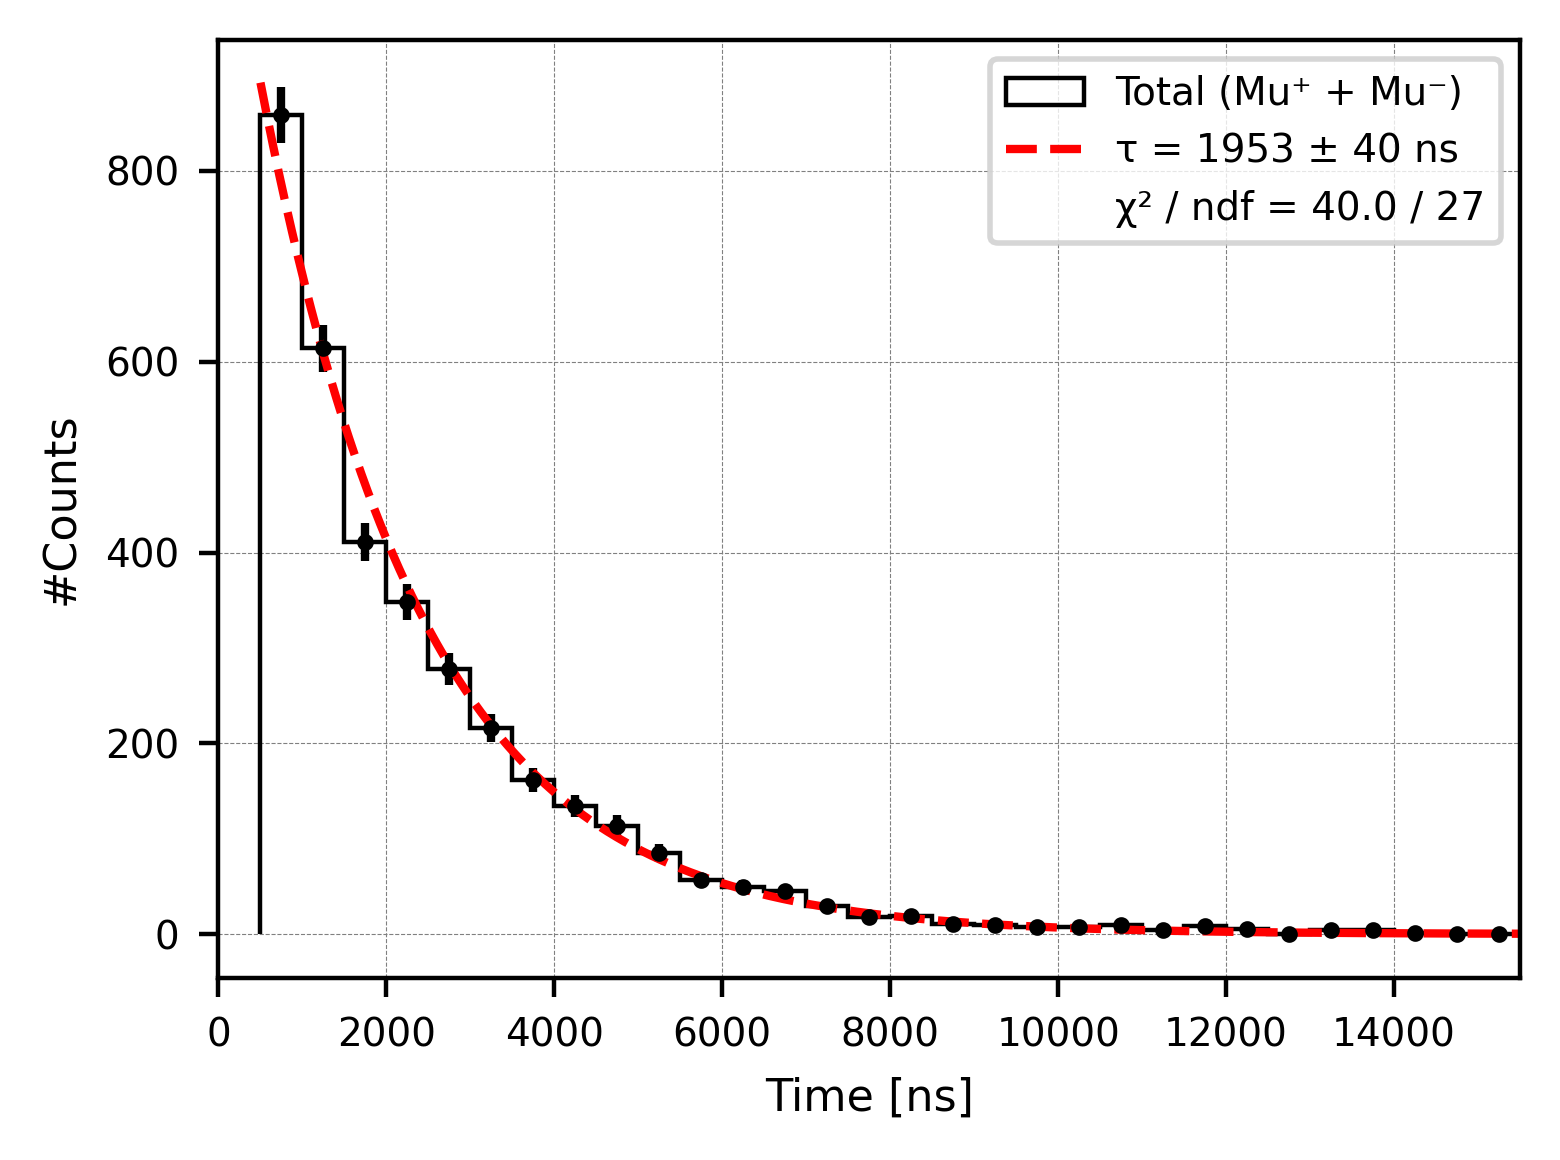

In [104]:

def fit_exponential_lifetime(
    data,
    bin_width=500,
    range_min=500,
    range_max=15500,
    plot_xmax=None,
    label='Muon Lifetime',
    color='blue',
    p0=None,
    show_plot=True,
    verbose=True
):
    """
    Fit an exponential lifetime distribution using least squares.

    Parameters
    ----------
    data : array-like
        Time samples (ns)
    bin_width : float
        Histogram bin width (ns)
    range_min, range_max : float
        Fit range (ns)
    label : str
        Label for plotting
    color : str
        Color for histogram & markers
    p0 : tuple or None
        Initial guess (N0, tau, C)
    show_plot : bool
        Whether to produce a plot
    verbose : bool
        Whether to print fit diagnostics

    Returns
    -------
    result : dict
        Dictionary containing fit results and statistics
    """

    # -----------------------------
    # Histogram
    # -----------------------------
    bins = np.arange(range_min, range_max + bin_width, bin_width)
    n, bin_edges = np.histogram(data, bins=bins)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Poisson uncertainties
    yerr = np.sqrt(n)
    yerr_plot = np.where(n == 0, 1.0, yerr)

    # -----------------------------
    # Fit model
    # -----------------------------
    def exp_func(t, N0, tau, C):
        return N0 * np.exp(-t / tau) + C

    if p0 is None:
        p0 = (np.max(n), 2000.0, 1.0)

    popt, pcov = curve_fit(
        exp_func,
        bin_centers,
        n,
        p0=p0,
        sigma=yerr_plot,
        absolute_sigma=True
    )

    perr = np.sqrt(np.diag(pcov))

    # -----------------------------
    # χ² calculation
    # -----------------------------
    expected = exp_func(bin_centers, *popt)
    expected = np.clip(expected, 1e-10, None)

    residuals = n - expected
    chi2 = np.sum((residuals / yerr_plot) ** 2)
    ndf = len(n) - len(popt)

    # -----------------------------
    # Print diagnostics
    # -----------------------------
    if verbose:
        print("\nLeast Square Fitting ==================")
        print(f"N0   = {popt[0]:.2f} ± {perr[0]:.2f}")
        print(f"tau  = {popt[1]:.2f} ± {perr[1]:.2f} ns")
        print(f"C    = {popt[2]:.2f} ± {perr[2]:.2f}")
        print(f"χ² / ndf = {chi2:.1f} / {ndf} = {chi2 / ndf:.2f}")

        print("\nBin-by-bin details:")
        for i in range(len(n)):
            print(
                f"Bin {i:2d}: "
                f"center={bin_centers[i]:6.0f} ns | "
                f"n={n[i]:6.0f} ± {yerr[i]:5.1f} | "
                f"exp={expected[i]:7.2f} | "
                f"res/σ={residuals[i] / yerr_plot[i]:6.2f}"
            )

    # -----------------------------
    # Plot
    # -----------------------------
    if show_plot:
        plt.figure(figsize=(4, 3), dpi=400)

        # Histogram
        hist_handle = plt.hist(
            data,
            bins=bins,
            histtype='step',
            linewidth=0.8,
            color=color,
            label=label
        )[2][0]

        plt.errorbar(
            bin_centers,
            n,
            yerr=yerr_plot,
            fmt='o',
            color=color,
            markersize=2
        )

        # Fit curve
        t_fit = np.linspace(range_min, range_max, 1000)
        fit_handle, = plt.plot(
            t_fit,
            exp_func(t_fit, *popt),
            '--',
            color='red',
            label=f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
        )


        # -----------------------------
        # Legend text entries
        # -----------------------------
        chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'
        dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)
        plt.legend(
            handles=[hist_handle, fit_handle, dummy_chi2],
            fontsize=7
        )

        plt.xlabel('Time [ns]', fontsize=8)
        plt.ylabel('#Counts', fontsize=8)

        xmax = plot_xmax if plot_xmax is not None else range_max
        plt.xlim(0, xmax)

        plt.tick_params(labelsize=7)
        plt.grid(color='gray', linestyle='--', linewidth=0.2)
        plt.xlim(0, range_max)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Return results
    # -----------------------------
    return {
        'popt': popt,
        'perr': perr,
        'chi2': chi2,
        'ndf': ndf,
        'bin_centers': bin_centers,
        'counts': n
    }



res_mu_plus = fit_exponential_lifetime(
    list_long,
    label='Mu⁺',
    color='blue',
    plot_xmax=16000
)



res_mu_minus = fit_exponential_lifetime(
    list_short,
    label='Mu⁻',
    color='red',
    p0=(5000, 600, 1),
    plot_xmax=16000
)



res_total = fit_exponential_lifetime(
    list_total,
    label='Total (Mu⁺ + Mu⁻)',
    color='black',
    plot_xmax=16000
)


### MC-like Simulation:

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ======================================
# True parameters (toy MC truth)
# ======================================
tau_long  = 2200.0   # ns (mu+)
tau_short = 570.0    # ns (mu-)

n_short = 850
n_long  = int(np.floor(n_short * 4.6))




# ==================================================
# Fitting function (single exponential + constant)
# ==================================================
def fit_exponential_lifetime(
    data,
    bin_width=500,
    range_min=500,
    range_max=15500,
    p0=None,
    show_plot=False,
    verbose=False
):
    # Histogram
    bins = np.arange(range_min, range_max + bin_width, bin_width)
    n, bin_edges = np.histogram(data, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Poisson uncertainties
    yerr = np.sqrt(n)
    yerr_plot = np.where(n == 0, 1.0, yerr)

    # Model
    def exp_func(t, N0, tau, C):
        return N0 * np.exp(-t / tau) + C

    if p0 is None:
        p0 = (np.max(n), 2000.0, 1.0)

    popt, pcov = curve_fit(
        exp_func,
        bin_centers,
        n,
        p0=p0,
        sigma=yerr_plot,
        absolute_sigma=True
    )

    perr = np.sqrt(np.diag(pcov))

    # χ²
    expected = exp_func(bin_centers, *popt)
    expected = np.clip(expected, 1e-10, None)
    residuals = n - expected
    chi2 = np.sum((residuals / yerr_plot) ** 2)
    ndf = len(n) - len(popt)

    return {
        'popt': popt,
        'perr': perr,
        'chi2': chi2,
        'ndf': ndf
    }







# =========================
# Toy Monte Carlo loop
# =========================
n_toys = 10000

mean_total_list = []
tau_fit_list    = []
tau_err_list    = []
chi2ndf_list    = []

for i in range(n_toys):

    # --- Generate samples ---
    sample_short = np.random.exponential(scale=tau_short, size=n_short)
    sample_long  = np.random.exponential(scale=tau_long,  size=n_long)

    list_total = np.concatenate([sample_long, sample_short])

    # --- Record mean ---
    mean_total_list.append(np.mean(list_total))

    # --- Fit ---
    res = fit_exponential_lifetime(
        list_total,
        show_plot=False,
        verbose=False
    )

    tau_fit = res['popt'][1]
    tau_err = res['perr'][1]
    chi2ndf = res['chi2'] / res['ndf']

    tau_fit_list.append(tau_fit)
    tau_err_list.append(tau_err)
    chi2ndf_list.append(chi2ndf)





Toy MC summary (100 experiments)
--------------------------------
Mean of <t>:        1908.4 ± 29.1 ns
Mean τ_fit:         1971.8 ± 42.7 ns
Mean σ(τ_fit):      41.8 ns
Mean χ²/ndf:        1.52
Pull mean:          1.51
Pull width (RMS):   0.73


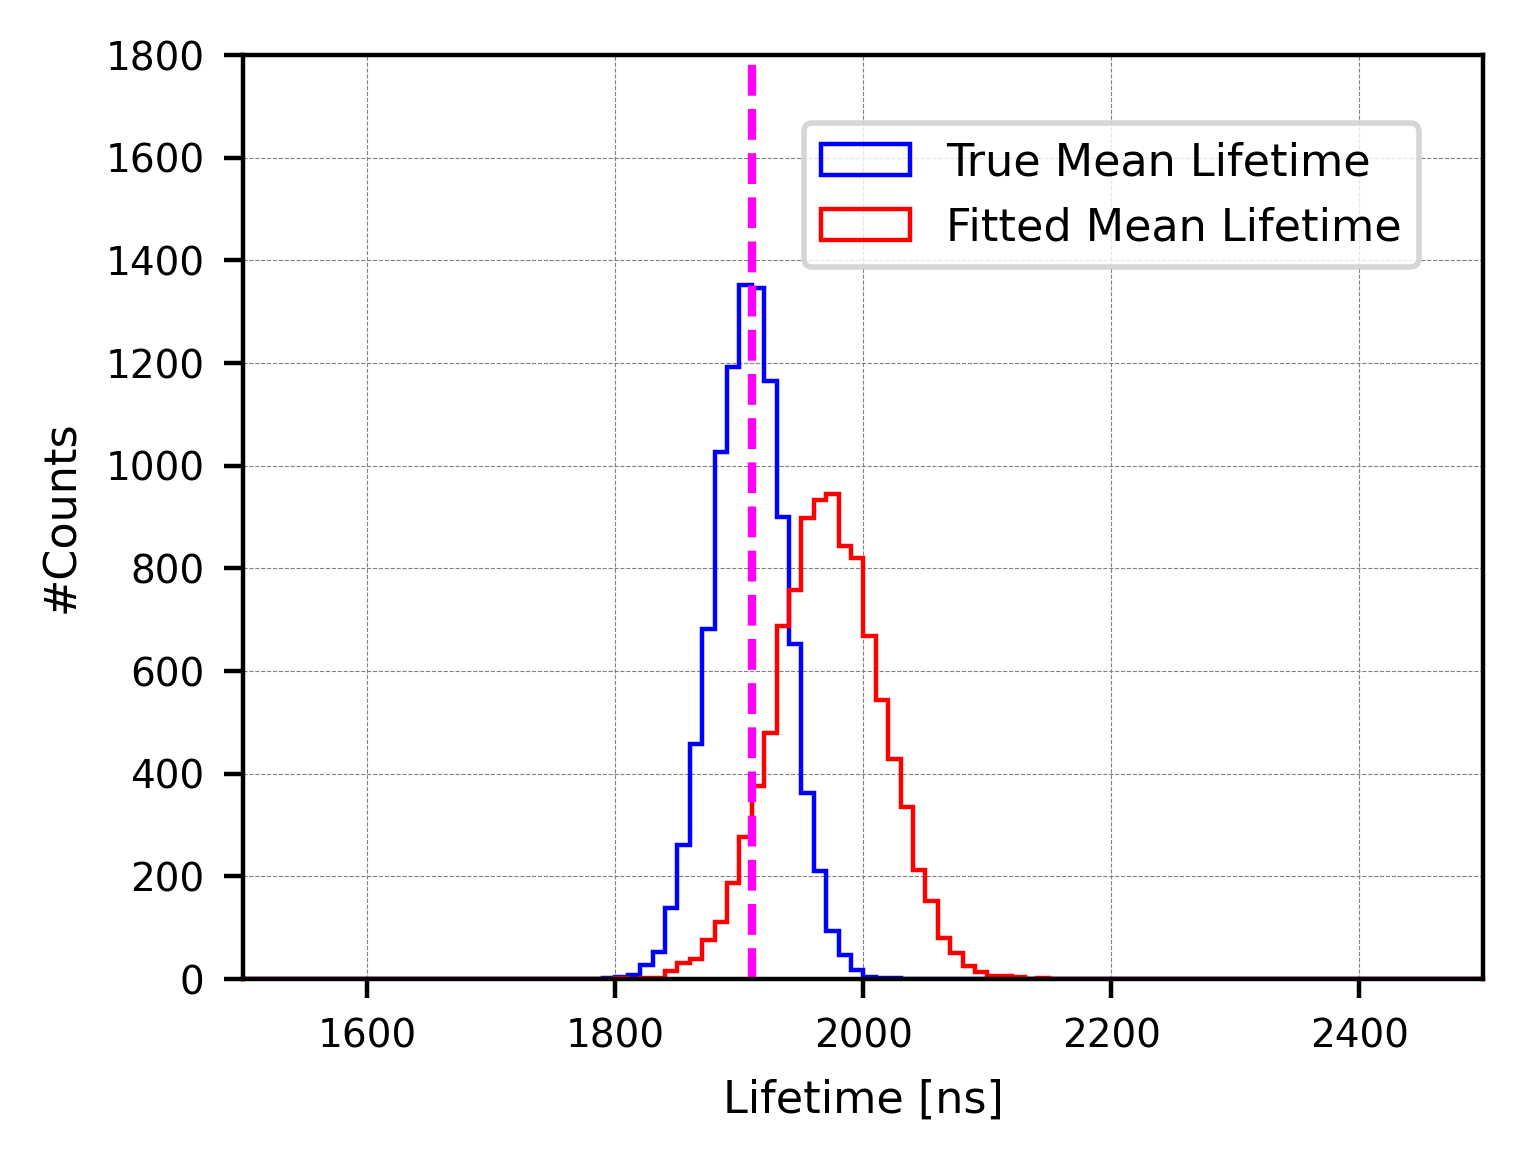

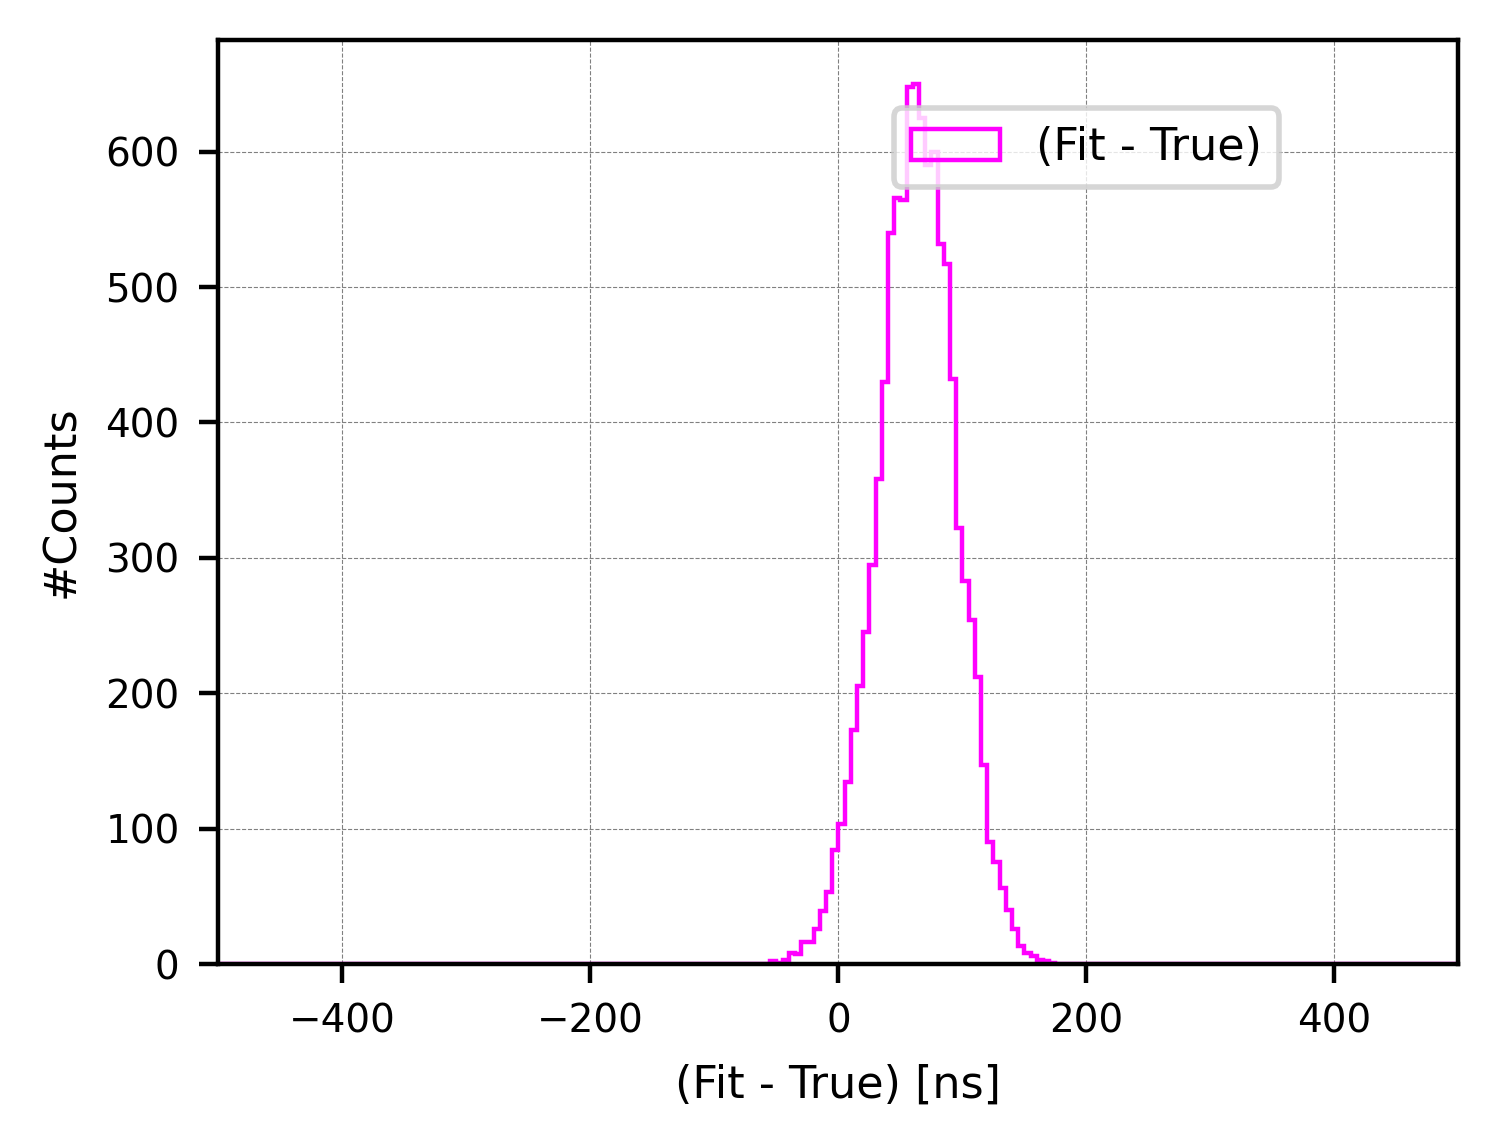

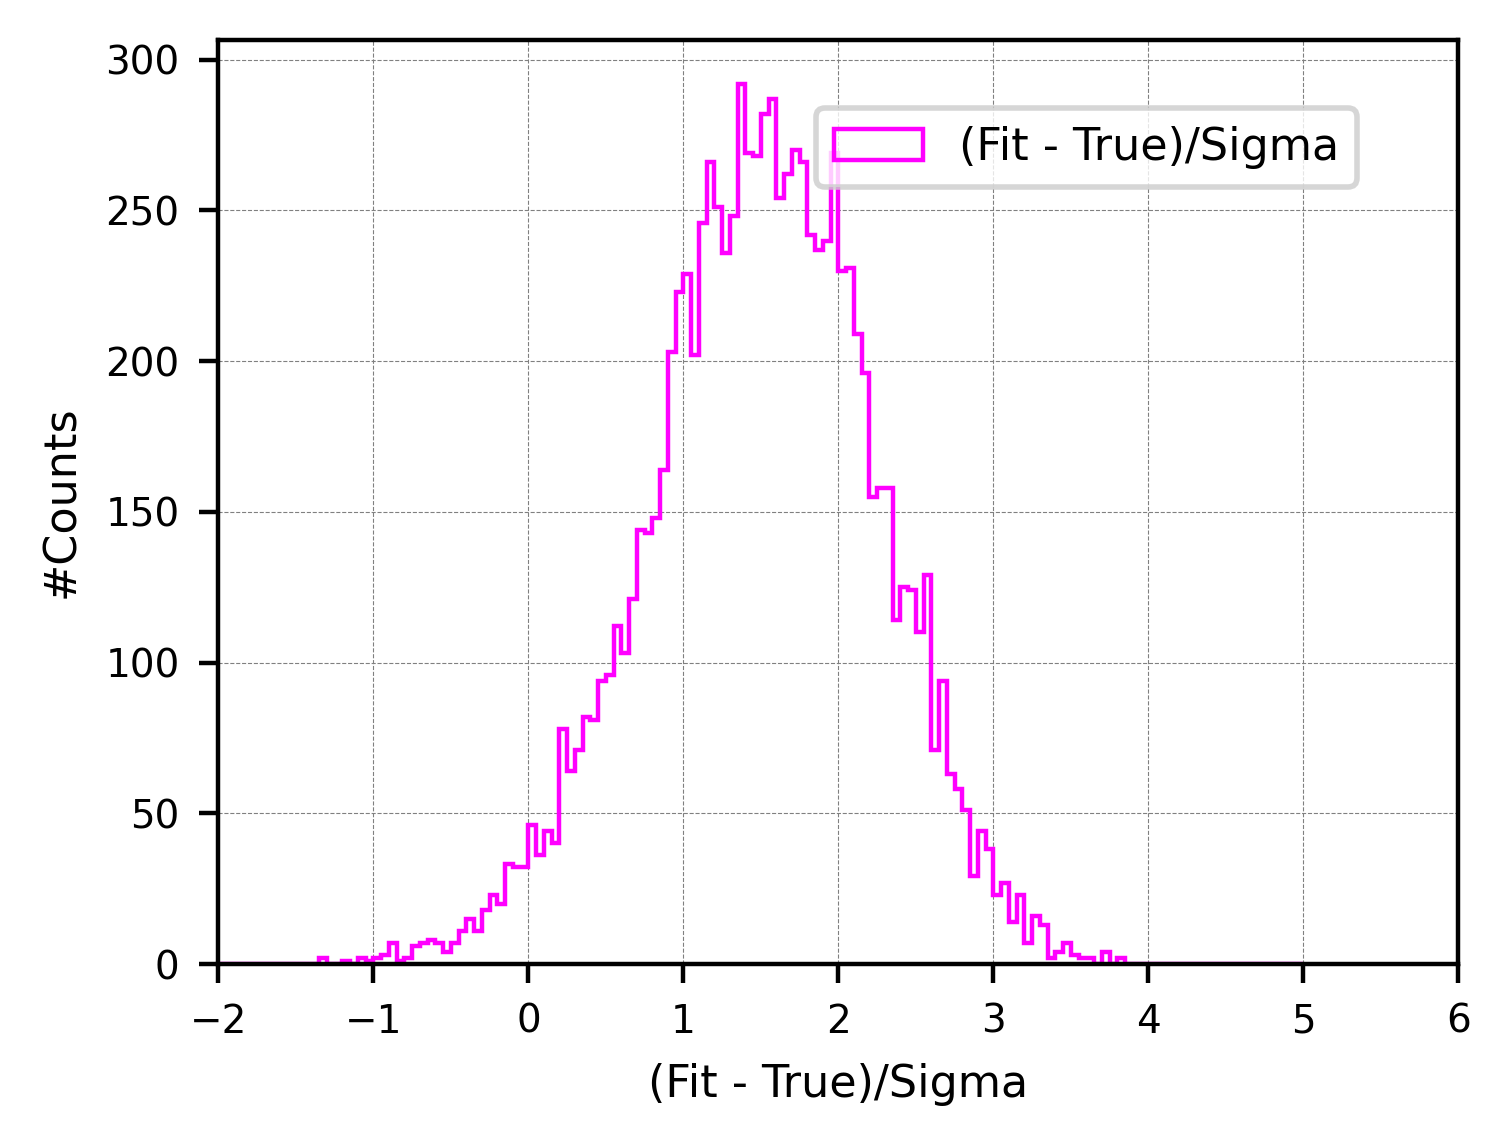

In [119]:
# ============================
# Summary diagnostics
# ============================
mean_total_list = np.array(mean_total_list)
tau_fit_list    = np.array(tau_fit_list)
tau_err_list    = np.array(tau_err_list)
chi2ndf_list    = np.array(chi2ndf_list)

diff = (tau_fit_list - mean_total_list)
pulls = (tau_fit_list - mean_total_list) / tau_err_list

print("Toy MC summary (100 experiments)")
print("--------------------------------")
print(f"Mean of <t>:        {np.mean(mean_total_list):.1f} ± {np.std(mean_total_list):.1f} ns")
print(f"Mean τ_fit:         {np.mean(tau_fit_list):.1f} ± {np.std(tau_fit_list):.1f} ns")
print(f"Mean σ(τ_fit):      {np.mean(tau_err_list):.1f} ns")
print(f"Mean χ²/ndf:        {np.mean(chi2ndf_list):.2f}")
print(f"Pull mean:          {np.mean(pulls):.2f}")
print(f"Pull width (RMS):   {np.std(pulls):.2f}")




#=====================================================
#True VS Fitted Values================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 10
range_min = 1000
range_max = 3000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mean_total_list, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='True Mean Lifetime')
plt.hist(tau_fit_list, bins=bins, range=(range_min, range_max),
         edgecolor='red', histtype='step', linewidth=0.8,
         label='Fitted Mean Lifetime')

plt.plot([1910, 1910], [0, 1800], color="magenta", linewidth=1.5, linestyle='--')

plt.xlim(1500, 2500)
plt.ylim(0, 1800)
plt.xlabel('Lifetime [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






#=====================================================
#(Reco - True)================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 5
range_min = -500
range_max = 500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(diff, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=0.8,
         label='(Fit - True)')



plt.xlim(-500, 500)
#plt.ylim(0, 400)
plt.xlabel('(Fit - True) [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






#=====================================================
#(Reco - True) / Sigma================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 0.05
range_min = -5
range_max = 5
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(pulls, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=0.8,
         label='(Fit - True)/Sigma')



plt.xlim(-2, 6)
#plt.ylim(0, 400)
plt.xlabel('(Fit - True)/Sigma', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()


